**Black Scholes calculations**

In [2]:
from IPython.display import HTML 
HTML("<style>div.input {display:none;}</style>")

In [3]:
import math
import pandas as pd
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D


def bs_call_price(S, K, r, T, sigma):
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm.cdf(d1) - K * math.exp(-r*T) * norm.cdf(d2)

def vega(S, K, r, T, sigma):
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    return S * norm.pdf(d1) * math.sqrt(T)

def implied_vol(St, Vt, K, TTE, r=0.0, initial_guess=0.2, tol=1e-3, max_iter=10):
    if St == None or Vt == None or K == None:
        return float("nan")
    sigma = initial_guess
    for _ in range(max_iter):
        price = bs_call_price(St, K, r, TTE, sigma)
        diff = price - Vt
        
        if abs(diff) < tol:
            return sigma
        
        sigma -= diff / vega(St, K, r, TTE, sigma)
    return float("nan")

def moneyness(K, St, TTE):
    moneyness = np.log(K/St) / np.sqrt(TTE)
    return moneyness

def safe_polyfit(row, deg=2):
    y_cols = ["iv_9500", "iv_9750", "iv_10000", "iv_10250", "iv_10500"]
    x_cols = ["m_9500", "m_9750", "m_10000", "m_10250", "m_10500"]
    x = row[x_cols].values
    y = row[y_cols].values
    
    mask = ~np.isnan(x) & ~np.isnan(y)
    
    if mask.sum() < deg + 1:
        return np.array([np.nan] * (deg + 1))
    
    return np.polyfit(x[mask], y[mask], deg)

**Calculate Implied Volatility against moneyness for each timestamp and fit the points to parabolic curve**

In [ ]:
def create_dataframes(day, timeframe):
    file = '/home/sjanschen/black_scholes_research/market_data/prices_round_3_day_' + str(day) + '.csv'
    df = pd.read_csv(file, delimiter=';')


    options = [9500, 9750, 10000, 10250, 10500]
    volcanic_rock = df[df['product'] == 'VOLCANIC_ROCK']
    df['St'] = (volcanic_rock['bid_price_1'] + volcanic_rock['ask_price_1']) / 2
    TTE = 7 - 3

    df3 = pd.DataFrame()

    for K in options:
        option = df[df['product'] == 'VOLCANIC_ROCK_VOUCHER_' + str(K)]
        df[f'Vt_{K}'] = (option['bid_price_1'] + option['ask_price_1']) / 2
        col1_clean = df[['timestamp', 'St']].dropna(subset=['St'])
        col2_clean = df[['timestamp', f'Vt_{K}']].dropna(subset=[f'Vt_{K}'])
        df2 = col1_clean.merge(col2_clean, on='timestamp', how='outer')
        df3[f"iv_{K}"] = [
            implied_vol(St, Vt, K, TTE)
            for St, Vt in zip(df2["St"].head(timeframe), df2[f'Vt_{K}'].head(timeframe))
        ]
        df3[f'm_{K}'] = moneyness(K, df2['St'].head(timeframe), TTE)
        df3[f'Vt_{K}'] = df2[f'Vt_{K}'].head(timeframe)

    df3['St'] = df2['St'].head(timeframe)
    df3['diff'] = df3['St'] / df3['Vt_9500']
    df3["poly_coeffs"] = df3.apply(safe_polyfit, axis=1)

    coeff_df = pd.DataFrame(df3["poly_coeffs"].tolist(),
                            columns=["a", "b", "c"])
    df3 = pd.concat([df3, coeff_df], axis=1)
    return df3

day = None
timeframe = 10000
# df = create_dataframes(day, timeframe)
# output_file = '/home/sjanschen/black_scholes_research/market_data/implied_vols_day_' + str(day) + '.csv'
# df.to_csv(output_file, sep=';')

**Average implied volatility against moneyness**

Each moneyness has an average implied volatility. Plotting every implied volatility gives us a volatility skew

Text(0.5, 1.0, 'Moneyness vs Implied Volatility for each option')

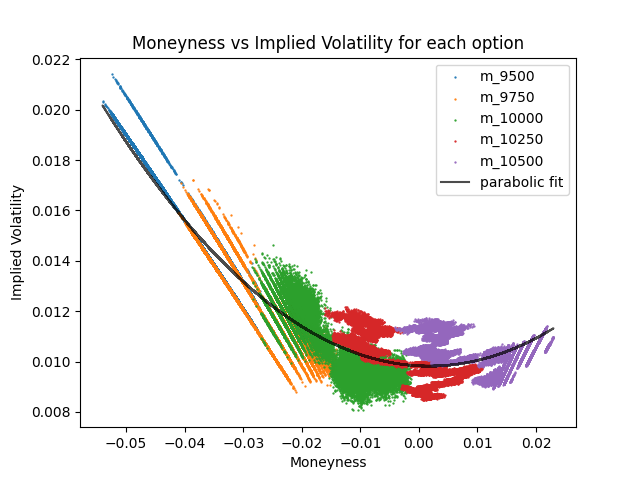

In [ ]:
df = pd.read_csv('/home/sjanschen/black_scholes_research/implied_vols_data/m_vs_iv.csv', delimiter=';').dropna()
x = df['m'].values
y = df['iv'].values
coeffs = np.polyfit(x, y, deg=2)
poly = np.poly1d(coeffs)
y_fit = poly(x)

colors = df['option'].astype('category').cat.codes
plt.figure()
for category in df['option'].unique(): 
    mask = df['option'] == category 
    plt.scatter(df.loc[mask, 'm'], df.loc[mask, 'iv'], label=category, s=0.4)

plt.plot(x, y_fit, label='parabolic fit', color='black', alpha=0.7)    
plt.legend()    
plt.xlabel("Moneyness")
plt.ylabel("Implied Volatility")
plt.title("Moneyness vs Implied Volatility for each option")

now that we know the parabolic curve of the volatility skewness for most moneyness' we should be able to determine a 'fair' price for each option. 
we should do that by plugging in the implied volatility at the given moneyness and use black-scholes to calculate the 'fair' price.
Then we should compare this 'fair' price to the actual price to spot mispricings and possibly use this as a trading signal.

Text(0.5, 1.0, 'Difference between actual IV and parabolic fit')

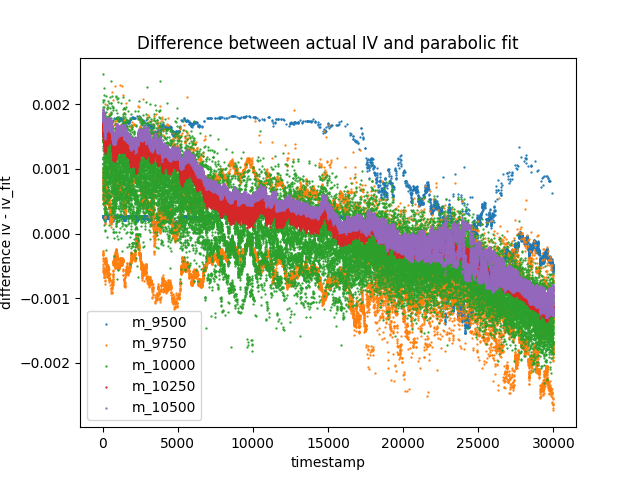

In [14]:
df = pd.read_csv('/home/sjanschen/black_scholes_research/implied_vols_data/m_vs_iv.csv', delimiter=';').dropna()
x = df['m'].values
y = df['iv'].values
coeffs = np.polyfit(x, y, deg=2)
iv_fit = np.polyval(coeffs, df['m'])
df['diff'] = df['iv'] - iv_fit
colors = df['option'].astype('category').cat.codes
plt.figure()
for category in df['option'].unique(): 
    mask = df['option'] == category
    plt.scatter(df.loc[mask, 'timestamp'], df.loc[mask, 'diff'], label=category, s=0.4)
plt.legend()
plt.xlabel("timestamp")
plt.ylabel("difference iv - iv_fit")
plt.title("Difference between actual IV and parabolic fit")

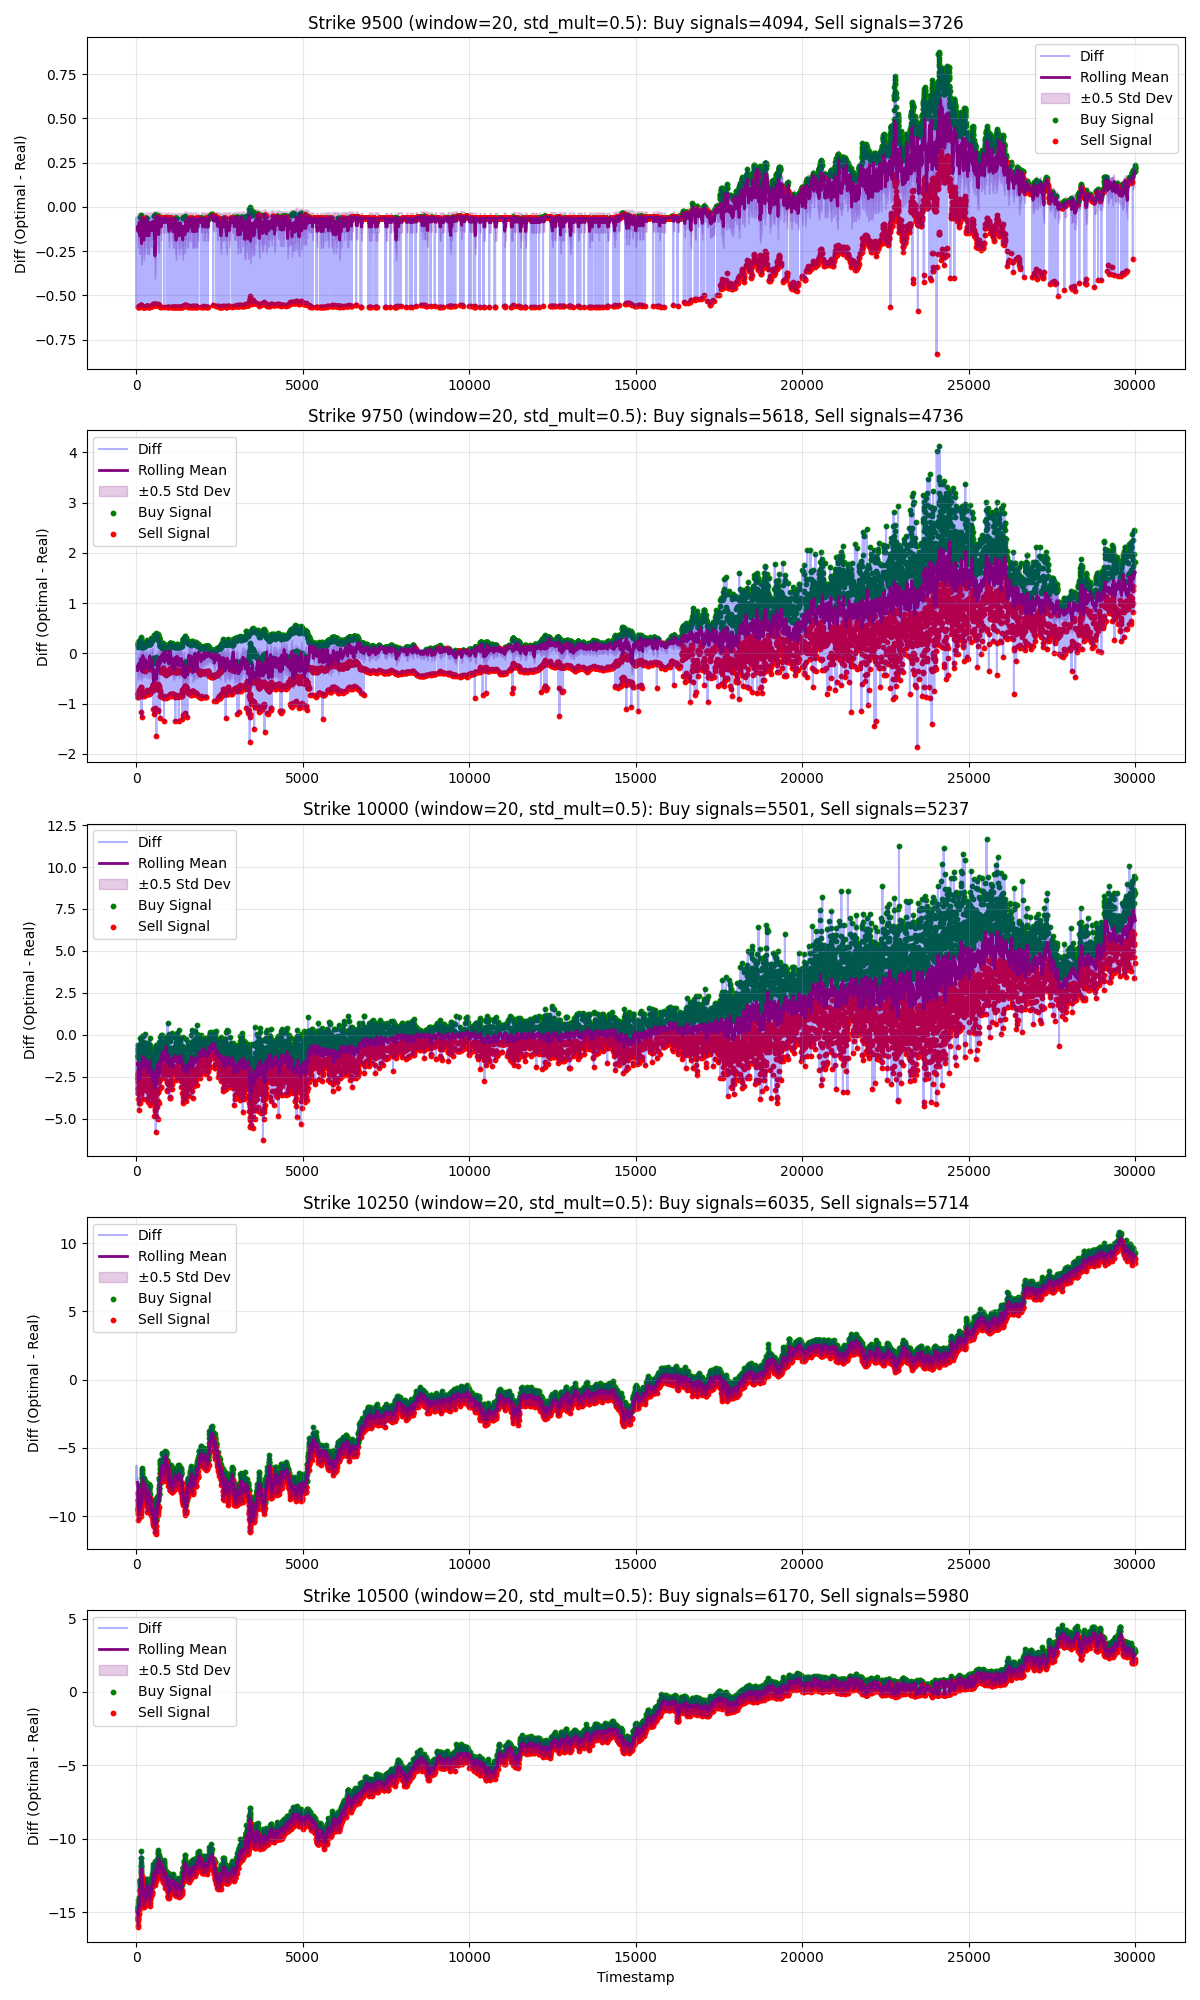

In [12]:
df = pd.read_csv('/home/sjanschen/black_scholes_research/implied_vols_data/implied_vols_combined.csv', delimiter=';').dropna()

strikes = [9500, 9750, 10000, 10250, 10500]
window = 20
std_multiplier = 0.5  # Control the std size here

fig, axes = plt.subplots(len(strikes), 1, figsize=(12, 4*len(strikes)))

for idx, K in enumerate(strikes):
    df[f'optimal_iv_{K}'] = np.polyval(coeffs, df[f'm_{K}'])
    df[f'optimal_bs_{K}'] = bs_call_price(df['St'], K, 0.0, 4, df[f'optimal_iv_{K}'])
    df[f'diff_{K}'] = df[f'optimal_bs_{K}'] - df[f'Vt_{K}']
    
    # Calculate rolling mean and std
    df[f'rolling_mean_{K}'] = df[f'diff_{K}'].rolling(window=window).mean()
    df[f'rolling_std_{K}'] = df[f'diff_{K}'].rolling(window=window).std(ddof=1)
    
    # Define thresholds as rolling mean ± std_multiplier * std
    df[f'signal_upper_{K}'] = df[f'rolling_mean_{K}'] + std_multiplier * df[f'rolling_std_{K}']
    df[f'signal_lower_{K}'] = df[f'rolling_mean_{K}'] - std_multiplier * df[f'rolling_std_{K}']
    
    # Trading signals
    buy = df[f'diff_{K}'] > df[f'signal_upper_{K}']
    sell = df[f'diff_{K}'] < df[f'signal_lower_{K}']

    buy_count = buy.sum()
    sell_count = sell.sum()
    
    ax = axes[idx] if len(strikes) > 1 else axes
    ax.plot(df['timestamp'], df[f'diff_{K}'], color='blue', alpha=0.3, label='Diff')
    ax.plot(df['timestamp'], df[f'rolling_mean_{K}'], color='purple', linewidth=2, label='Rolling Mean')
    ax.fill_between(df['timestamp'], df[f'signal_lower_{K}'], df[f'signal_upper_{K}'], 
                     alpha=0.2, color='purple', label='±{:.1f} Std Dev'.format(std_multiplier))
    ax.scatter(df.loc[buy, 'timestamp'], df.loc[buy, f'diff_{K}'], color='green', 
              label='Buy Signal', s=10)
    ax.scatter(df.loc[sell, 'timestamp'], df.loc[sell, f'diff_{K}'], color='red', 
              label='Sell Signal', s=10)
    ax.set_title(f'Strike {K} (window={window}, std_mult={std_multiplier}): Buy signals={buy_count}, Sell signals={sell_count}')
    ax.set_ylabel('Diff (Optimal - Real)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.xlabel('Timestamp')
plt.tight_layout()